# Linear Models of Returns

### Overview

This notebook shows a worked example of estimating the factor model given by:

$$\mathbf{r_t} = \boldsymbol{\alpha} + \mathbf{B} \mathbf{f_t} + \boldsymbol{\epsilon_t}$$

(equation (4.1) in (Paleologo (2025)), with $\mathbf{r_t}$ being the vector of asset excess returns, $\mathbf{B}$ the nxm loadings matrix, $\boldsymbol{\alpha}$ the n-dimensional alpha vector, $\mathbf{f_t}$ the vector of m factor returns and $\boldsymbol{\epsilon_t}$ the random vector of n idiosyncratic returns (Paleologo (2025)).

Our $\mathbf{B}$ comes from a factor model with 10 factors plus sector weights, calculated monthly for a subset of the S&P 500 stock index, with the following factors:

1. <b>Profitability</b> Operating profitability is (revenues - [Cost of Goods Sold] - [selling, general, and administrative expenses] - [interest expense])/[book equity] (Fama and French (2015)).

1. <b>Investment</b>
The change in Total Assets from the fiscal year ending in (t-2) to the fiscal year ending in (t-1), divided by (t-1) total assets.

1. <b>Value</b>
Defined as book value = Stockholders Equity / Market Capitalisation

1. <b>Size</b>
The market capitalisation. 

1. <b>Momentum</b>
Measuring price momentum, as the 12 month trailing return excluding the most recent month. 

1. <b>Beta</b> The beta from CAPM regressed against the broad S&P500 index over the previous 252 trading days.  

1. <b>Volatility</b> The residual volatility from the CAPM model calculated over the previous 252 trading days. 

1. <b>Growth</b> The growth in Total Revenue over the previous 12 months. 

1. <b>Leverage/Financial Health</b> Financial health is measured by Total Debt / Total Assets.

1. <b>Liquidity</b> Liquidity is measured as |daily return| / daily dollar volume

1. <b>Sector classification</b> Each sector is included in $B$ as a sparsely encoded column vector (1 if the stock is in that sector, 0 if not).

The factors were chosen to provide a broad coverage of fundamental and stylistic factor types, and the python module 'data_pipeline.py' has the calculation logic. 

### Roadmap

The sections that follow show how the factor data can be used to build a cross sectional $\mathbf{B}$ panel of factors for a given date, to allow estimation of $\mathbf{f_t}$ in the equation above. The notebook then goes on to show how this can be repeated over a number of dates, to allow the idiosyncratic covariance matrix $\boldsymbol{\Omega_\epsilon}$ and the factor covariance matrix $\boldsymbol{\Omega_f}$ to be estimated. 

### Data
The stock population for this example is a subset of 427 of the stocks in the S&P 500, selected for survivability during the period 2010 - 2016, in the interests of simplifying the data ingestion. The list of tickers can be found in the factor_data folder. The survivorship bias this introduces is obviously considerable and the data would need to be fully adjusted for survivorship before these calculations could be moved into a production environment. Also, the data have not been thoroughly checked for corporate actions and events and again this would need to be done in a live system. The objective of this notebook is to build a working example of a factor model.  

To be conservative, a lag of 3 months was applied to any accounting data ingested to account for delays in filing. 

Fundamental and accounting data was accessed via Mathematica (which in turn curates a collection of institutional providers), with prices and volumes accessed from yahoo finance.

The raw inputs to the data_pipeline.py module have not been uploaded to github to honour licensing, but the derived factor values are available in the factor_data folder. 

### <u><b>Reference list</b></u>

Paleologo, G.A., 2025. The Elements of Quantitative Investing. John Wiley & Sons.

Fama, E.F. and French, K.R., 2015. A five-factor asset pricing model. Journal of financial economics, 116(1), pp.1-22.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from python.factor_builder import FactorBuilder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We begin by creating a FactorBuilder class, a utility class that allows panel data to be easily calculated for a specified date. The factor data is available from each month end from January 2012 to March 2026.  

In [70]:
fb = FactorBuilder("./factor_data/factor_data.csv")
B = fb.build_cross_sectional_panel(pd.to_datetime("2020-03-31"))
B.head()

,beta,resid_vol,Value_BM,Profitability_OP,Investment_CMA,Momentum_12_1,Growth_Rev,Leverage_DA,Liquidity,MarketCap,...,DiversifiedFinancialServices,Energy,AutomobilesAndComponents,Banks,RealEstateManagementAndDevelopment,HouseholdAndPersonalProducts,MediaAndEntertainment,TelecommunicationServices,ConsumerStaplesDistributionAndRetail,ConsumerDurablesAndApparel
ticker,,,,,,,,,,,,,,,,,,,,,
A,1.657138,0.120905,-0.235678,-0.060982,-0.304060,-0.689516,-0.085793,-0.042118,-0.048422,-0.076860,...,0,0,0,0,0,0,0,0,0,0
AAL,0.977123,1.194700,-0.661608,0.062793,-0.694648,-2.012878,-0.084464,1.157012,-0.048365,-0.176393,...,0,0,0,0,0,0,0,0,0,0
AAP,-1.147466,-0.095340,-0.279463,-0.048735,0.807921,0.364713,-0.164638,-0.620875,-0.048419,-0.265222,...,0,0,0,0,0,0,0,0,0,0
AAPL,-0.879686,-0.169893,-0.264743,-0.053644,1.564030,0.775021,0.820482,-1.392509,-0.048440,4.571753,...,0,0,0,0,0,0,0,0,0,0
ABT,-1.464059,-0.458598,-0.063464,-0.071997,-0.030074,1.128254,-1.677892,0.185553,-0.048438,0.138870,...,0,0,0,0,0,0,0,0,0,0


We also need prices for the regression. These are resampled to month end dates to be consistent with the factor data:


In [ ]:
class StockReturnGenerator:
    """
    Utiliity class for retrieving stock returns
    """
    def __init__(self, monthly_price_path: str="./data_files/monthly_prices.csv", tickers_path: str="./factor_data/ticker_list.csv"):
        self.monthly_prices =  pd.read_csv(monthly_price_path,parse_dates=["date"], index_col="date")
        self.tickers = pd.read_csv(tickers_path)["ticker"].to_list()

    def get_1m_returns(self, start_date :pd.Timestamp) -> pd.DataFrame:
        """
        retrieve the 1m returns for the period starting at start date as a vector
        """
        p = self.monthly_prices[self.tickers]
        start_date = start_date.normalize()
        end_date = pd.to_datetime(start_date) + pd.offsets.MonthEnd(1)
        end_date = end_date.normalize()
        r = p.loc[end_date]/p.loc[start_date] - 1.0
        r = r.reindex(self.tickers)
        return r
    
    def get_date_list(self, end_date: pd.Timestamp, window: int) -> list[pd.Timestamp]:
        """
        Returns a list of 'window' monthly dates up to and including the end_date
        """
        end_date = end_date.normalize()
        date_series = pd.date_range(end=end_date, periods=window, freq='ME')
        return date_series.to_list()

stock_return_gen = StockReturnGenerator()

Calculate $\mathbf{r_t}$ for the period after the panel data:

In [69]:
r_t = stock_return_gen.get_1m_returns(pd.to_datetime("2023-03-31"))

Now we can perform our single-period regression, with OLS:

In [68]:
f, residuals, rank, s = np.linalg.lstsq(B, r_t, rcond=None)

and we can calculate $R^2$ and $\epsilon$ for the fit:

In [64]:
r_hat = B @ f # f is the fitted factor vector  
eps = r_t - r_hat # calculate epsilon, the residual vector
ss_res = np.sum(eps**2) 
ss_tot = np.sum((r_t - np.mean(r_t))**2)
r2 = 1.0 - ss_res / ss_tot
r2

np.float64(0.3218927818170809)

To understand the factor loadings, we can label with the columns of $\mathbf{B}$ and plot:

<Axes: >

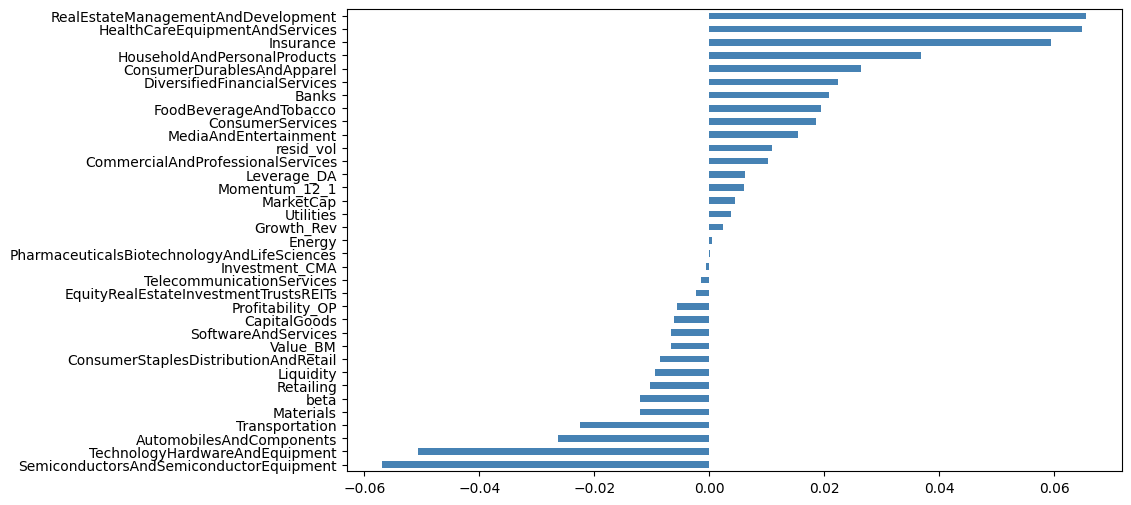

In [12]:
f_series = pd.Series(f, index=B.columns, name="factor_return")
f_series_sorted = f_series.sort_values()
f_series_sorted.plot(kind='barh', figsize=(10, 6), color='steelblue')

As explained in Chapter 6 of (Paleologo (2005)), the regression above is the first step in our estimation process. 

We now repeat this regression at each $t = 1, ... , T$. At each step we perform a cross-sectional regression of $\mathbf{r_t}$ (the returns between t and t+1) against $\mathbf{B_t}$ (the loadings availble at time t-1), and  obtain vectors $\mathbf{\hat{f_t}}$ and $\boldsymbol{\hat{\epsilon_t}}$ at each step. 

Then, from the time series of $\mathbf{\hat{f_t}}$ and $\boldsymbol{\hat{\epsilon}_t}$ we can estimate:
1. The factor covariance matrix $\boldsymbol{\hat{\Omega}_{f,t}}$
2. The idiosyncratic covariance matrix $\boldsymbol{\hat{\Omega}_{\epsilon,t}}$
3. the risk-adjusted performace of factor returns.

In [134]:
run_dates = stock_return_gen.get_date_list(pd.to_datetime("2017-12-31"),window=60)

f_list = []
eps_list = []

# we run the OLS regression first T times
for d in run_dates:
    B_t = fb.build_cross_sectional_panel(d)
    r_t = stock_return_gen.get_1m_returns(start_date = pd.to_datetime(d))
    f_t, _, _, _ = np.linalg.lstsq(B_t, r_t, rcond=None)
    eps_t = r_t - B_t @ f_t

    f_list.append(np.array(f_t).reshape(1,-1))
    eps_list.append(np.array(eps_t).reshape(1,-1))

# F, the time series of f_t is Txm
F = pd.DataFrame(np.vstack(f_list), index=run_dates)
# E, the time series of eps_t is Txn (n = number of assets)
E = pd.DataFrame(np.vstack(eps_list), index=run_dates)

We can now estimate the factor covariance matrix $\boldsymbol{{\hat{\Omega}_{f}}}$ and the idiosyncratic matrix $\boldsymbol{{\hat{\Omega}_{\epsilon}}}$. 

#### Step A: Factor Covariance Matrix

The book notes that the estimate $var(\mathbf{\hat{f}_t})$ is biased:

$$var(\mathbf{\hat{f}_t}) = \boldsymbol{{\hat{\Omega}_{f}}} + (\mathbf{B}^T\boldsymbol{{\hat{\Omega}_{\epsilon}^{-1}}}\mathbf{B})^{-1}$$

and recommends applying Ledoit-Wolf shrinkage:

$$\boldsymbol{{\hat{\Omega}_{f,shrink}}}(\rho) = (1-\rho)\boldsymbol{\hat{\Omega}_f} + \rho\frac{trace(\boldsymbol{\hat{\Omega}_f})}{m}\mathbf{I_m}$$

#### Step B: Idiosyncratic Matrix

The process for the idiosyncratic matrix is iterative, as the matrix is both and input and an output of the regression process. In performing our initial OLS regression, we are assuming a diagonal structure for $\boldsymbol{\Omega_{\epsilon}}$ and so we enforce this and then reperform the regression, this time using Weighted Least Squared (WLS).  

The following function provides initial esimates for the factor covariance matrix and the idiosyncratic matrix.

In [128]:
def estimate_covariance_matrices(F: pd.DataFrame, E: pd.DataFrame, 
                                 shrinkage_rho: float=0.1) -> tuple[pd.DataFrame, np.array, np.array]:
    # 1. Factor Covariance Matrix (m x m)
    # Start with sample covariance
    omega_f_emp = F.cov().values
    
    # Apply Ledoit-Wolf Style Shrinkage to the factor matrix
    m = omega_f_emp.shape[0]
    prior = np.eye(m) * np.trace(omega_f_emp) / m
    Omega_f = (1 - shrinkage_rho) * omega_f_emp + shrinkage_rho * prior
    
    # 2. Idiosyncratic Covariance Matrix (n x n)
    # Calculate variance for each asset (column) in E
    idio_variances = E.var(axis=0).values
    # In a factor model, we assume residuals are uncorrelated (diagonal)
    Omega_eps = np.diag(idio_variances)
    Omega_eps_inv = np.diag(1.0 / idio_variances)
    
    return Omega_f, Omega_eps, Omega_eps_inv


We obtain our estimated covariance matrices:

In [135]:
Omega_f, Omega_eps, Omega_eps_inv = estimate_covariance_matrices(F, E)

and repeat the regressions, this time with WLS. For each time $t$ we now have:

$$\mathbf{\hat{f_t}} = (\mathbf{B}^T\boldsymbol{\Omega}_\epsilon^{-1}\mathbf{B})^{-1}\mathbf{B}^T \boldsymbol{\Omega}_\epsilon^{-1} \mathbf{r}_t$$

so that the stocks are weighted by the inverse of the intial estimate of the idiosyncratic risk.

In [136]:
f_list_wls = []
eps_list_wls = []

# run the WLS regression, weighting by Omega_eps_inv
for d in run_dates:
    B_t = fb.build_cross_sectional_panel(d)
    r_t = stock_return_gen.get_1m_returns(start_date = pd.to_datetime(d))
    
    # Calculate components for WLS
    # We solve the system (B.T @ W @ B)f = B.T @ W @ r
    # where W = Omega_eps_inv 

    lhs = B_t.values.T @ Omega_eps_inv @ B_t.values
    rhs = B_t.values.T @ Omega_eps_inv @ r_t

    # f_t_wls shape will be (m,1)
    f_t_wls = np.linalg.solve(lhs, rhs)

    # calculate the final residuals
    eps_t_wls = r_t - (B_t @ f_t_wls)

    f_list_wls.append(f_t_wls.T) # transpose to (1, m)
    eps_list_wls.append(eps_t_wls.T) # transpose to (1, n)

# final data frames
F_final = pd.DataFrame(np.vstack(f_list_wls), index=run_dates)
E_final = pd.DataFrame(np.vstack(eps_list_wls), index=run_dates) 

### Example Applications

#### Example 1. Factor performance analysis

The cumulative returns of the non-sector factors are shown below. 

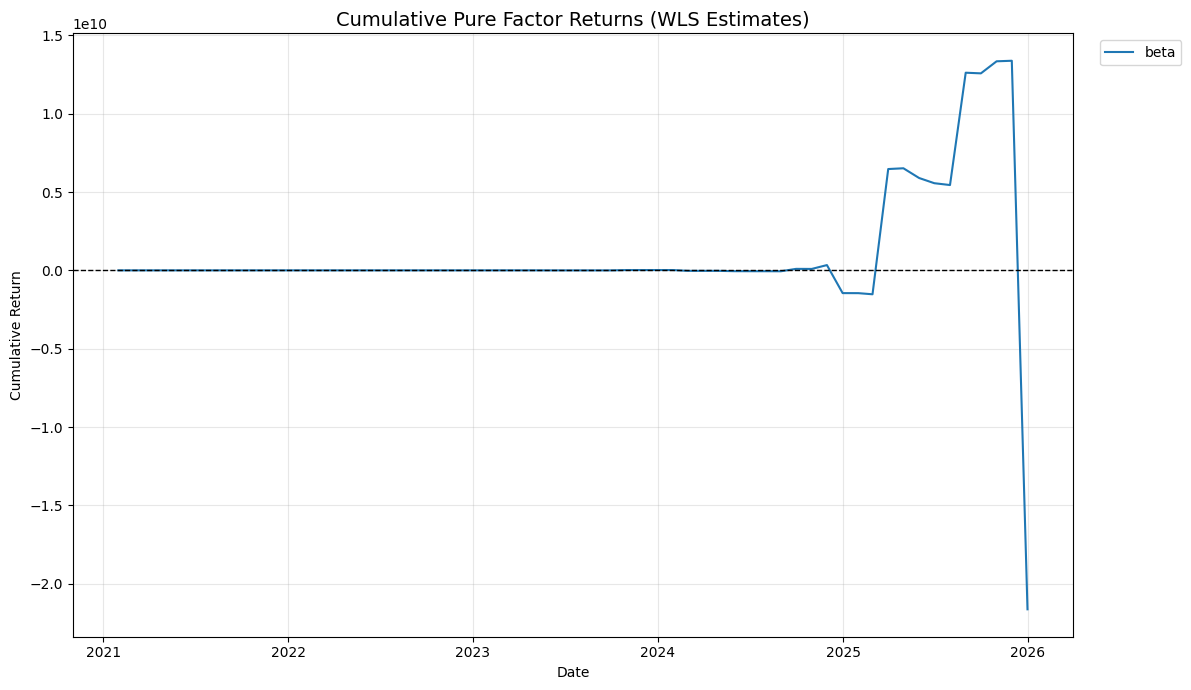

In [133]:
F_copy = F_final.copy()
F_copy.columns = B_t.columns
stylistic_factors = F_copy.columns[:1]

# calculate cumulative factor returns for the stylistic factors
cum_factor_returns = (1 + F_copy[stylistic_factors]).cumprod() - 1

# plot cumulative factor returns
plt.figure(figsize=(12,7))
for factor in stylistic_factors:
    plt.plot(cum_factor_returns.index, cum_factor_returns[factor], label=factor)
    
plt.title('Cumulative Pure Factor Returns (WLS Estimates)', fontsize=14)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Example 2. Ex-Ante Portfolio Risk Decomposition

This example creates a simple equal-weighted portfolio and decomposes its total risk into Systematic (Factor) Risk and Idiosyncratic (Specific) Risk.

In [126]:
# Re-estimate final covariance matrices using the WLS results
Omega_f_final, Omega_eps_final, _ = estimate_covariance_matrices(F_final, E_final, shrinkage_rho=0.5)

# Create an equal-weighted portfolio of the latest available stocks
n_stocks = B_t.shape[0]
w = np.ones(n_stocks) / n_stocks  # Portfolio weight vector

# 1. Calculate Systematic (Factor) Variance
# Formula: w^T * (B * Omega_f * B^T) * w
# More efficiently, calculate portfolio factor exposures first: w_f = B^T * w
port_factor_exposures = B_t.T @ w
sys_var = port_factor_exposures.T @ Omega_f_final @ port_factor_exposures

# 2. Calculate Idiosyncratic Variance
# Formula: w^T * Omega_eps * w
idio_var = w.T @ Omega_eps_final @ w

# 3. Total Variance & Decomposition
total_var = sys_var + idio_var
sys_risk_pct = (sys_var / total_var) * 100
idio_risk_pct = (idio_var / total_var) * 100

# Annualize the total portfolio volatility
total_vol_ann = np.sqrt(total_var) * np.sqrt(12)

print("Ex-Ante Portfolio Risk Decomposition (Equal-Weighted)")
print("=" * 55)
print(f"Total Annualized Volatility:            {total_vol_ann:.2%}")
print("-" * 55)
print(f"Proportion from Systematic Factors:     {sys_risk_pct:.1f}%")
print(f"Proportion from Idiosyncratic Risk:     {idio_risk_pct:.1f}%")

Ex-Ante Portfolio Risk Decomposition (Equal-Weighted)
Total Annualized Volatility:            21835758.79%
-------------------------------------------------------
Proportion from Systematic Factors:     90.6%
Proportion from Idiosyncratic Risk:     9.4%
